In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Basic libs
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

csv_path = "/content/drive/MyDrive/TongueImagediabetes/clinical/diabetes_prediction_dataset (2).csv"
df = pd.read_csv(csv_path)

df.head(), df.info()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              10000 non-null  float64
 1   bmi              10000 non-null  float64
 2   gender           10000 non-null  object 
 3   smoking_history  10000 non-null  object 
 4   hypertension     10000 non-null  int64  
 5   heart_disease    10000 non-null  int64  
 6   diabetes         10000 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 547.0+ KB


(    age    bmi  gender smoking_history  hypertension  heart_disease  diabetes
 0  80.0  34.65  female           never             0              0         1
 1  56.0  33.30  female           never             0              0         0
 2  44.0  24.31    male         current             0              0         0
 3  31.0  28.92    male          former             0              0         0
 4  66.0  29.95  female           never             1              0         0,
 None)

In [ ]:
# Separate features and target
y = df["diabetes"].values
X = df.drop(columns=["diabetes"])

print("Features:", X.columns.tolist())
print("Target shape:", y.shape)

# Train / val / test = 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train size:", X_train.shape[0])
print("Val size:  ", X_val.shape[0])
print("Test size: ", X_test.shape[0])


Features: ['age', 'bmi', 'gender', 'smoking_history', 'hypertension', 'heart_disease']
Target shape: (10000,)
Train size: 7000
Val size:   1500
Test size:  1500


In [ ]:
numeric_features = ['age', 'bmi', 'hypertension', 'heart_disease']
categorical_features = ['gender', 'smoking_history']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

# Fit on train, transform all splits
X_train_proc = preprocess.fit_transform(X_train)
X_val_proc   = preprocess.transform(X_val)
X_test_proc  = preprocess.transform(X_test)

# If OneHotEncoder returns sparse matrices, convert to dense
if not isinstance(X_train_proc, np.ndarray):
    X_train_proc = X_train_proc.toarray()
    X_val_proc   = X_val_proc.toarray()
    X_test_proc  = X_test_proc.toarray()

print("Train processed shape:", X_train_proc.shape)
print("Val processed shape:  ", X_val_proc.shape)
print("Test processed shape: ", X_test_proc.shape)


Train processed shape: (7000, 10)
Val processed shape:   (1500, 10)
Test processed shape:  (1500, 10)


In [ ]:
class ClinicalTabularDataset(Dataset):
    def __init__(self, X_array, y_array):
        self.X = torch.tensor(X_array, dtype=torch.float32)
        self.y = torch.tensor(y_array, dtype=torch.float32)  # for BCEWithLogits

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ClinicalTabularDataset(X_train_proc, y_train)
val_ds   = ClinicalTabularDataset(X_val_proc,   y_val)
test_ds  = ClinicalTabularDataset(X_test_proc,  y_test)

print("Train samples:", len(train_ds))
print("Val samples:  ", len(val_ds))
print("Test samples: ", len(test_ds))

# Central loaders for evaluation
val_loader  = DataLoader(val_ds,  batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)


Train samples: 7000
Val samples:   1500
Test samples:  1500


In [ ]:
def split_indices_for_clients(num_samples, num_clients):
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    return np.array_split(indices, num_clients)

def get_client_loader(base_dataset, client_indices, batch_size=64):
    client_dataset = Subset(base_dataset, client_indices)
    loader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)
    return loader

NUM_CLIENTS = 3  # you can change this

client_splits = split_indices_for_clients(len(train_ds), NUM_CLIENTS)
for i, split in enumerate(client_splits):
    print(f"Client {i}: {len(split)} samples")


Client 0: 2334 samples
Client 1: 2333 samples
Client 2: 2333 samples


In [ ]:
input_dim = X_train_proc.shape[1]

class ClinicalNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)   # single logit for binary classification
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (batch,)

# Sanity check
tmp_model = ClinicalNet(input_dim)
print("Number of parameters:", sum(p.numel() for p in tmp_model.parameters()))
del tmp_model


Number of parameters: 193


In [ ]:
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def local_train_one_client(
    global_model,
    train_loader,
    device=device,
    epochs_local=1,
    lr=1e-3,
):
    # Start from global model weights
    model = ClinicalNet(input_dim)
    model.load_state_dict(global_model.state_dict())
    model.to(device)
    model.train()

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs_local):
        running_loss = 0.0
        total = 0

        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            total += yb.size(0)

        epoch_loss = running_loss / total
        print(f"    Local epoch {epoch+1} loss: {epoch_loss:.4f}")

    num_examples = len(train_loader.dataset)
    return model.state_dict(), num_examples


Using device: cpu


In [ ]:
def fedavg(state_dicts, weights):
    """
    state_dicts: list of model.state_dict() from each client
    weights:     list of number of examples per client
    """
    total_weight = float(sum(weights))
    avg_state = copy.deepcopy(state_dicts[0])

    for k in avg_state.keys():
        avg_state[k] = sum(
            w * sd[k] for sd, w in zip(state_dicts, weights)
        ) / total_weight

    return avg_state


In [ ]:
def eval_clinical_model(model, loader, device=device):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    running_loss = 0.0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * yb.size(0)

            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu())
            all_targets.append(yb.cpu())

    probs = torch.cat(all_probs).numpy()
    targets = torch.cat(all_targets).numpy()

    avg_loss = running_loss / len(loader.dataset)
    auroc = roc_auc_score(targets, probs)
    auprc = average_precision_score(targets, probs)
    acc = accuracy_score(targets, (probs >= 0.5).astype(int))

    print(f"  [Eval] loss: {avg_loss:.4f}, AUROC: {auroc:.4f}, AUPRC: {auprc:.4f}, ACC: {acc:.4f}")
    return avg_loss, auroc, auprc, acc


In [ ]:
def federated_train_clinical_model(
    base_train_dataset,
    client_splits,
    num_rounds=5,
    epochs_local=1,
    batch_size=64,
    lr=1e-3,
    device=device,
):
    global_model = ClinicalNet(input_dim).to(device)

    val_losses = []
    val_aurocs = []
    val_auprcs = []
    val_accs   = []

    for rnd in range(num_rounds):
        print(f"\n=== Federated Round {rnd+1}/{num_rounds} ===")

        client_states = []
        client_sizes  = []

        for cid, idxs in enumerate(client_splits):
            print(f"\n  Client {cid} training on {len(idxs)} samples")
            client_loader = get_client_loader(base_train_dataset, idxs, batch_size=batch_size)

            state_dict, n_examples = local_train_one_client(
                global_model,
                client_loader,
                device=device,
                epochs_local=epochs_local,
                lr=lr,
            )

            client_states.append(state_dict)
            client_sizes.append(n_examples)

        # FedAvg aggregation
        new_global_state = fedavg(client_states, client_sizes)
        global_model.load_state_dict(new_global_state)

        # Evaluate on central validation set
        v_loss, v_auroc, v_auprc, v_acc = eval_clinical_model(global_model, val_loader, device=device)
        val_losses.append(v_loss)
        val_aurocs.append(v_auroc)
        val_auprcs.append(v_auprc)
        val_accs.append(v_acc)

    return global_model, val_losses, val_aurocs, val_auprcs, val_accs


In [ ]:
NUM_ROUNDS   = 5
EPOCHS_LOCAL = 1
BATCH_SIZE   = 128
LR           = 1e-3

global_clinical_model, val_losses, val_aurocs, val_auprcs, val_accs = federated_train_clinical_model(
    base_train_dataset=train_ds,
    client_splits=client_splits,
    num_rounds=NUM_ROUNDS,
    epochs_local=EPOCHS_LOCAL,
    batch_size=BATCH_SIZE,
    lr=LR,
    device=device,
)



=== Federated Round 1/5 ===

  Client 0 training on 2334 samples
    Local epoch 1 loss: 0.7228

  Client 1 training on 2333 samples
    Local epoch 1 loss: 0.7232

  Client 2 training on 2333 samples
    Local epoch 1 loss: 0.7207
  [Eval] loss: 0.7100, AUROC: 0.3520, AUPRC: 0.4105, ACC: 0.4047

=== Federated Round 2/5 ===

  Client 0 training on 2334 samples
    Local epoch 1 loss: 0.7024

  Client 1 training on 2333 samples
    Local epoch 1 loss: 0.7021

  Client 2 training on 2333 samples
    Local epoch 1 loss: 0.7014
  [Eval] loss: 0.6915, AUROC: 0.5534, AUPRC: 0.5539, ACC: 0.5187

=== Federated Round 3/5 ===

  Client 0 training on 2334 samples
    Local epoch 1 loss: 0.6845

  Client 1 training on 2333 samples
    Local epoch 1 loss: 0.6823

  Client 2 training on 2333 samples
    Local epoch 1 loss: 0.6842
  [Eval] loss: 0.6746, AUROC: 0.6855, AUPRC: 0.6591, ACC: 0.6333

=== Federated Round 4/5 ===

  Client 0 training on 2334 samples
    Local epoch 1 loss: 0.6671

  Client

In [ ]:
print("\n=== Final Global Model on TEST set ===")
test_loss, test_auroc, test_auprc, test_acc = eval_clinical_model(
    global_clinical_model, test_loader, device=device
)



=== Final Global Model on TEST set ===
  [Eval] loss: 0.6378, AUROC: 0.7743, AUPRC: 0.7448, ACC: 0.7047


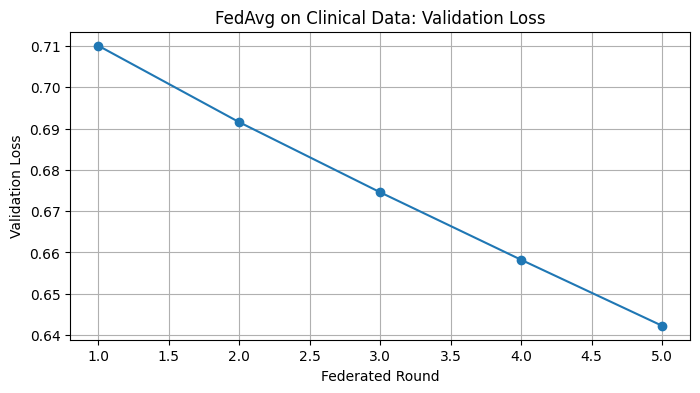

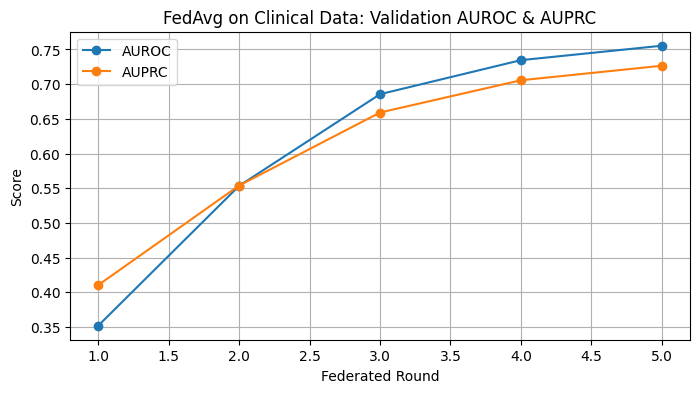

In [ ]:
import matplotlib.pyplot as plt

rounds = range(1, len(val_losses) + 1)

plt.figure(figsize=(8,4))
plt.plot(rounds, val_losses, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Validation Loss")
plt.title("FedAvg on Clinical Data: Validation Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(rounds, val_aurocs, marker='o', label='AUROC')
plt.plot(rounds, val_auprcs, marker='o', label='AUPRC')
plt.xlabel("Federated Round")
plt.ylabel("Score")
plt.title("FedAvg on Clinical Data: Validation AUROC & AUPRC")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Centralised training (no federated learning)

def train_centralized_model(
    train_dataset,
    num_epochs=10,
    batch_size=128,
    lr=1e-3,
    device=device,
):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = ClinicalNet(input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            total += yb.size(0)

        epoch_loss = running_loss / total
        epoch_losses.append(epoch_loss)
        print(f"[Central] Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f}")

    return model, epoch_losses

# Run centralised training
CENTRAL_EPOCHS = 10
central_model, central_train_losses = train_centralized_model(
    train_ds,
    num_epochs=CENTRAL_EPOCHS,
    batch_size=128,
    lr=1e-3,
    device=device,
)


[Central] Epoch 1/10 - loss: 0.6505
[Central] Epoch 2/10 - loss: 0.5971
[Central] Epoch 3/10 - loss: 0.5639
[Central] Epoch 4/10 - loss: 0.5501
[Central] Epoch 5/10 - loss: 0.5456
[Central] Epoch 6/10 - loss: 0.5433
[Central] Epoch 7/10 - loss: 0.5420
[Central] Epoch 8/10 - loss: 0.5413
[Central] Epoch 9/10 - loss: 0.5407
[Central] Epoch 10/10 - loss: 0.5401


In [ ]:
print("\n=== CENTRAL model on TEST set ===")
central_test_loss, central_test_auroc, central_test_auprc, central_test_acc = eval_clinical_model(
    central_model, test_loader, device=device
)

print("\n=== FEDERATED (global) model on TEST set ===")
fed_test_loss, fed_test_auroc, fed_test_auprc, fed_test_acc = eval_clinical_model(
    global_clinical_model, test_loader, device=device
)

print("\n=== Summary (Test set) ===")
print(f"Centralised: loss={central_test_loss:.4f}, AUROC={central_test_auroc:.4f}, AUPRC={central_test_auprc:.4f}, ACC={central_test_acc:.4f}")
print(f"Federated :  loss={fed_test_loss:.4f}, AUROC={fed_test_auroc:.4f}, AUPRC={fed_test_auprc:.4f}, ACC={fed_test_acc:.4f}")



=== CENTRAL model on TEST set ===
  [Eval] loss: 0.5338, AUROC: 0.8075, AUPRC: 0.7784, ACC: 0.7293

=== FEDERATED (global) model on TEST set ===
  [Eval] loss: 0.6378, AUROC: 0.7743, AUPRC: 0.7448, ACC: 0.7047

=== Summary (Test set) ===
Centralised: loss=0.5338, AUROC=0.8075, AUPRC=0.7784, ACC=0.7293
Federated :  loss=0.6378, AUROC=0.7743, AUPRC=0.7448, ACC=0.7047


In [ ]:
import os
import torch

save_dir = "/content/drive/MyDrive/federated_clinical_models"
os.makedirs(save_dir, exist_ok=True)

# Paths
fed_model_path      = os.path.join(save_dir, "global_federated_clinical_model.pt")
central_model_path  = os.path.join(save_dir, "central_clinical_model.pt")

# Save only state_dict (weights)
torch.save(global_clinical_model.state_dict(), fed_model_path)
torch.save(central_model.state_dict(), central_model_path)

print("Saved federated model to:", fed_model_path)
print("Saved central model to:   ", central_model_path)


Saved federated model to: /content/drive/MyDrive/federated_clinical_models/global_federated_clinical_model.pt
Saved central model to:    /content/drive/MyDrive/federated_clinical_models/central_clinical_model.pt


In [ ]:
import joblib

preprocess_path = os.path.join(save_dir, "clinical_preprocess.joblib")
joblib.dump(preprocess, preprocess_path)

print("Saved preprocessing pipeline to:", preprocess_path)


Saved preprocessing pipeline to: /content/drive/MyDrive/federated_clinical_models/clinical_preprocess.joblib


In [ ]:
import joblib
import torch

# Load preprocess
preprocess = joblib.load(preprocess_path)

# Rebuild model and load weights
loaded_model = ClinicalNet(input_dim)
loaded_model.load_state_dict(torch.load(fed_model_path))
loaded_model.eval()


ClinicalNet(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)